# Cluster Asset Impact Analysis Pipeline_hmm

Sequence-aware HMM asset pipeline.

This version keeps weekly HMM states and joins weekly activity assets so you can analyze:
- assets used while developers are in each HMM state
- assets used before and after HMM state transitions
- developer-level journey profiles by dominant HMM state

Important interpretation rule:
- `from_state` and `to_state` are the actual HMM transition
- `stratum` and `adoption_direction` are external lifecycle labels carried over from the HMM journey export
- they describe the developer cohort, not where the HMM state is transitioning to


## 1. Setup And Parameters

This section loads the libraries, defines the HMM source parquet files, names the output tables, and creates the DuckDB connection.


In [20]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

DB_PATH = 'developer_project.duckdb'
HMM_WEEKLY_SOURCE = 'toexport_clusters/dev_hmm_weekly_states_v1.parquet'
HMM_JOURNEY_SOURCE = 'toexport_clusters/dev_hmm_developer_journey_v1.parquet'
PROFILE_TABLE = 'dev_profile_final_v4'
ACTIVITY_TABLE = 'activity_final'

HMM_STATE_LABEL_TABLE = 'hmm_state_labels_v2'
HMM_WEEKLY_TABLE = 'hmm_weekly_state_base_v2'
HMM_ACTIVITY_ASSET_CATALOG_TABLE = 'hmm_activity_asset_catalog_v2'
HMM_ACTIVITY_EVENTS_WEEKLY_TABLE = 'hmm_activity_events_weekly_v2'
HMM_STATE_ASSET_LONG_TABLE = 'hmm_state_asset_long_v2'
HMM_STATE_ASSET_USAGE_TABLE = 'hmm_asset_usage_by_state_v2'
HMM_TRANSITION_EVENT_TABLE = 'hmm_transition_events_v2'
HMM_TRANSITION_SUMMARY_TABLE = 'hmm_transition_summary_v2'
HMM_TRANSITION_CONTEXT_TABLE = 'hmm_transition_context_summary_v2'
HMM_PRE_TRANSITION_ASSET_TABLE = 'hmm_asset_pre_transition_v2'
HMM_PRE_TRANSITION_ASSET_CONTEXT_TABLE = 'hmm_asset_pre_transition_context_v2'
HMM_POST_TRANSITION_ASSET_TABLE = 'hmm_asset_post_transition_v2'
HMM_POST_TRANSITION_ASSET_CONTEXT_TABLE = 'hmm_asset_post_transition_context_v2'
HMM_TRANSITION_ASSET_DELTA_TABLE = 'hmm_asset_transition_delta_v2'
HMM_DOMINANT_STATE_PROFILE_TABLE = 'hmm_dominant_state_profile_v2'

HMM_STATE_LABELS = {
    0: 'Idle / Minimal Weekly Activity',
    1: 'Low Recent Activity / Lapsing',
    2: 'Light At-Risk Engagement',
    3: 'Cooling / Declining Engagement',
    4: 'Active Exploration Burst',
    5: 'Build-Oriented Weekly Usage',
    6: 'Prior Active / Starting Engagement',
    7: 'Irregular / Noisy Weekly Activity',
}

PRE_WEEKS = 4
POST_WEEKS = 4
MIN_TRANSITIONS_PER_PAIR = 100

con = duckdb.connect(DB_PATH)


## 2. Validate Required Inputs

This section confirms that the required local tables exist and that the HMM weekly, HMM journey, and activity sources have the columns needed for the sequence-aware pipeline.


In [21]:
available_tables = set(con.execute('SHOW TABLES').fetchdf()['name'].tolist())
required_tables = [PROFILE_TABLE, ACTIVITY_TABLE]
missing_tables = [t for t in required_tables if t not in available_tables]
if missing_tables:
    raise ValueError(f'Missing required tables: {missing_tables}')

weekly_cols = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{HMM_WEEKLY_SOURCE}')").fetchdf()['column_name'].tolist()
journey_cols = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{HMM_JOURNEY_SOURCE}')").fetchdf()['column_name'].tolist()
activity_cols = con.execute(f"PRAGMA table_info({ACTIVITY_TABLE})").fetchdf()['name'].tolist()

for cols, req, name in [
    (weekly_cols, ['developer_id', 'week_start', 'hmm_hidden_state', 'hmm_state_probability'], HMM_WEEKLY_SOURCE),
    (journey_cols, ['developer_id', 'dominant_hmm_state', 'first_hmm_state', 'last_hmm_state', 'hmm_state_entropy', 'stratum', 'adoption_direction'], HMM_JOURNEY_SOURCE),
    (activity_cols, ['dev_contact', 'activity', 'activity_date', 'activity_score'], ACTIVITY_TABLE),
]:
    missing = [c for c in req if c not in cols]
    if missing:
        raise ValueError(f'Missing required columns in {name}: {missing}')

display(pd.DataFrame({'required_table': required_tables}))
display(con.execute(f"SELECT developer_id, week_start, hmm_hidden_state, hmm_state_probability FROM read_parquet('{HMM_WEEKLY_SOURCE}') LIMIT 5").fetchdf())


,required_table
0,dev_profile_final_v4
1,activity_final


,developer_id,week_start,hmm_hidden_state,hmm_state_probability
0,047e118b82c918a12e8ff838f6275c0d454cc39c3b6b89...,2023-10-23,0,0.545891
1,047e118b82c918a12e8ff838f6275c0d454cc39c3b6b89...,2023-10-30,2,0.385295
2,047e118b82c918a12e8ff838f6275c0d454cc39c3b6b89...,2023-11-06,2,0.541590
3,047e118b82c918a12e8ff838f6275c0d454cc39c3b6b89...,2023-11-13,2,0.617142
4,047e118b82c918a12e8ff838f6275c0d454cc39c3b6b89...,2023-11-27,2,0.654515


## 3. Build Labeled HMM Weekly Base And Weekly Asset Events

This section creates readable HMM state labels, builds the weekly HMM base table, maps dated activities into weekly asset events, and joins those assets back to every developer-week HMM state.


In [22]:
label_df = pd.DataFrame([
    {'hmm_state': state, 'hmm_state_label': label}
    for state, label in HMM_STATE_LABELS.items()
])
con.register('hmm_state_label_df_view', label_df)
con.execute(f'CREATE OR REPLACE TABLE {HMM_STATE_LABEL_TABLE} AS SELECT * FROM hmm_state_label_df_view')

asset_catalog = pd.DataFrame([
    ('dli_training', 'learning_activity', 'course_engagement'),
    ('webinar', 'learning_activity', 'event_learning'),
    ('devzone_download', 'download_activity', 'download'),
    ('ngc_download', 'download_activity', 'download'),
    ('forum_contribution', 'community_activity', 'community'),
    ('bug_filed', 'community_activity', 'community'),
    ('hackathon', 'community_activity', 'community'),
    ('live_event', 'event_activity', 'live_event'),
    ('ondemand_view', 'content_activity', 'content'),
    ('model_api', 'product_activity', 'api_usage'),
    ('program_membership', 'program_activity', 'program'),
    ('product_specific_comms', 'marketing_activity', 'comms'),
    ('contest', 'community_activity', 'community')
], columns=['asset_name', 'asset_group', 'asset_role'])

con.register('hmm_activity_asset_catalog_df_view', asset_catalog)
con.execute(f'CREATE OR REPLACE TABLE {HMM_ACTIVITY_ASSET_CATALOG_TABLE} AS SELECT * FROM hmm_activity_asset_catalog_df_view')

con.execute(f"""
CREATE OR REPLACE TABLE {HMM_WEEKLY_TABLE} AS
SELECT
    w.developer_id,
    CAST(w.week_start AS DATE) AS week_start,
    CAST(w.hmm_hidden_state AS BIGINT) AS hmm_state,
    w.hmm_state_probability,
    w.gmm_weekly_cluster_id,
    w.gmm_weekly_max_posterior,
    w.emission_code,
    j.dominant_hmm_state,
    j.first_hmm_state,
    j.last_hmm_state,
    j.avg_state_probability,
    j.hmm_state_entropy,
    j.stratum,
    j.cluster_key,
    j.adoption_direction,
    p.persona,
    p.behavior_journey_stage_30d,
    p.current_journey_state_30d,
    p.dormancy_status,
    p.developer_effort_level
FROM read_parquet('{HMM_WEEKLY_SOURCE}') w
LEFT JOIN read_parquet('{HMM_JOURNEY_SOURCE}') j USING (developer_id)
LEFT JOIN {PROFILE_TABLE} p USING (developer_id)
""")

con.execute(f"""
CREATE OR REPLACE TABLE {HMM_ACTIVITY_EVENTS_WEEKLY_TABLE} AS
WITH mapped AS (
    SELECT
        CAST(dev_contact AS VARCHAR) AS developer_id,
        CAST(DATE_TRUNC('week', activity_date) AS DATE) AS week_start,
        CASE
            WHEN lower(activity) = 'dli training' THEN 'dli_training'
            WHEN lower(activity) = 'webinars' THEN 'webinar'
            WHEN lower(activity) = 'devzone downloads' THEN 'devzone_download'
            WHEN lower(activity) = 'ngc downloads' THEN 'ngc_download'
            WHEN lower(activity) = 'forum contributions' THEN 'forum_contribution'
            WHEN lower(activity) = 'bugs filed' THEN 'bug_filed'
            WHEN lower(activity) = 'hackathons' THEN 'hackathon'
            WHEN lower(activity) IN ('conf. sessions live', 'conference', 'other events', 'event registrations') THEN 'live_event'
            WHEN lower(activity) = 'on-demand views' THEN 'ondemand_view'
            WHEN lower(activity) = 'model api' THEN 'model_api'
            WHEN lower(activity) = 'dev program membership' THEN 'program_membership'
            WHEN lower(activity) = 'product specific comms' THEN 'product_specific_comms'
            WHEN lower(activity) = 'contests' THEN 'contest'
            ELSE NULL
        END AS asset_name,
        COUNT(*) AS event_count,
        SUM(COALESCE(activity_score, 0.0)) AS activity_score_sum
    FROM {ACTIVITY_TABLE}
    WHERE activity_date IS NOT NULL
    GROUP BY 1,2,3
)
SELECT * FROM mapped WHERE asset_name IS NOT NULL
""")

con.execute(f"""
CREATE OR REPLACE TABLE {HMM_STATE_ASSET_LONG_TABLE} AS
SELECT
    b.developer_id, b.week_start, b.hmm_state, b.hmm_state_probability,
    b.dominant_hmm_state, b.first_hmm_state, b.last_hmm_state, b.hmm_state_entropy,
    b.stratum, b.cluster_key, b.adoption_direction, b.persona, b.behavior_journey_stage_30d,
    b.current_journey_state_30d, b.dormancy_status, b.developer_effort_level,
    a.asset_name, a.asset_group, a.asset_role,
    COALESCE(e.event_count, 0) AS event_count,
    COALESCE(e.activity_score_sum, 0.0) AS activity_score_sum,
    CASE WHEN COALESCE(e.event_count, 0) > 0 THEN 1 ELSE 0 END AS used_asset_flag
FROM {HMM_WEEKLY_TABLE} b
CROSS JOIN {HMM_ACTIVITY_ASSET_CATALOG_TABLE} a
LEFT JOIN {HMM_ACTIVITY_EVENTS_WEEKLY_TABLE} e
  ON b.developer_id = e.developer_id
 AND b.week_start = e.week_start
 AND a.asset_name = e.asset_name
""")

display(con.execute(f'SELECT COUNT(*) AS weekly_rows, COUNT(DISTINCT developer_id) AS distinct_developers FROM {HMM_WEEKLY_TABLE}').fetchdf())
display(con.execute(f'SELECT COUNT(*) AS activity_week_rows, COUNT(DISTINCT asset_name) AS distinct_assets FROM {HMM_ACTIVITY_EVENTS_WEEKLY_TABLE}').fetchdf())


,weekly_rows,distinct_developers
0,916268,150000


,activity_week_rows,distinct_assets
0,20043578,13


## 4. State-Level Usage And Transition Pair Summary

This section summarizes asset usage while developers are in each HMM state and then builds the main `from_state -> to_state` transition tables. The main transition table is pure HMM movement; lifecycle context is split out separately.


### Top Assets Within Each HMM State

,hmm_state,state_label,asset_name,asset_group,asset_role,developer_weeks,exposed_developer_weeks,distinct_developers_seen,distinct_developers_using_asset,exposure_rate,avg_event_count_when_used,avg_score_when_used,asset_rank_within_state
0,0,Idle / Minimal Weekly Activity,devzone_download,download_activity,download,33037,15420.0,24387,11482,0.466749,4.260700,11.605123,1
1,0,Idle / Minimal Weekly Activity,program_membership,program_activity,program,33037,6779.0,24387,6602,0.205194,1.057383,1.175690,2
2,0,Idle / Minimal Weekly Activity,live_event,event_activity,live_event,33037,3037.0,24387,2742,0.091927,2.645044,26.349029,3
3,0,Idle / Minimal Weekly Activity,dli_training,learning_activity,course_engagement,33037,1756.0,24387,1605,0.053153,1.514237,41.617312,4
4,0,Idle / Minimal Weekly Activity,product_specific_comms,marketing_activity,comms,33037,1542.0,24387,1348,0.046675,1.118677,3.356031,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,7,Irregular / Noisy Weekly Activity,ondemand_view,content_activity,content,10468,203.0,3476,167,0.019392,3.512315,75.458128,6
76,7,Irregular / Noisy Weekly Activity,dli_training,learning_activity,course_engagement,10468,181.0,3476,162,0.017291,1.403315,31.933702,7
77,7,Irregular / Noisy Weekly Activity,live_event,event_activity,live_event,10468,131.0,3476,120,0.012514,4.877863,225.076336,8
78,7,Irregular / Noisy Weekly Activity,webinar,learning_activity,event_learning,10468,62.0,3476,54,0.005923,1.209677,8.145161,9


### Most Frequent Transition Pairs

,from_state,to_state,from_state_label,to_state_label,transitions,distinct_developers,pct_within_from_state,same_state_flag
0,1,1,Low Recent Activity / Lapsing,Low Recent Activity / Lapsing,150165,56576,0.999368,1
1,6,1,Prior Active / Starting Engagement,Low Recent Activity / Lapsing,36968,36966,0.863194,0
2,2,2,Light At-Risk Engagement,Light At-Risk Engagement,21207,6452,0.979086,1
3,3,3,Cooling / Declining Engagement,Cooling / Declining Engagement,11787,2872,0.959853,1
4,7,5,Irregular / Noisy Weekly Activity,Build-Oriented Weekly Usage,5817,2552,0.984264,0
5,5,7,Build-Oriented Weekly Usage,Irregular / Noisy Weekly Activity,4425,1719,0.887485,0
6,0,6,Idle / Minimal Weekly Activity,Prior Active / Starting Engagement,3819,3818,0.538798,0
7,6,6,Prior Active / Starting Engagement,Prior Active / Starting Engagement,3144,3033,0.073412,1
8,0,0,Idle / Minimal Weekly Activity,Idle / Minimal Weekly Activity,2155,1998,0.304035,1
9,6,2,Prior Active / Starting Engagement,Light At-Risk Engagement,1474,1474,0.034418,0


### Transition Pair Context Breakout

,from_state,to_state,from_state_label,to_state_label,stratum,adoption_direction,transitions,distinct_developers,pct_within_transition_pair
0,1,1,Low Recent Activity / Lapsing,Low Recent Activity / Lapsing,dormant,steady_inactive,53569,28879,0.356734
1,1,1,Low Recent Activity / Lapsing,Low Recent Activity / Lapsing,active,accelerating_or_active,45800,9318,0.304998
2,1,1,Low Recent Activity / Lapsing,Low Recent Activity / Lapsing,at_risk,at_risk,37538,14482,0.249978
3,6,1,Prior Active / Starting Engagement,Low Recent Activity / Lapsing,dormant,steady_inactive,19989,19989,0.540711
4,1,1,Low Recent Activity / Lapsing,Low Recent Activity / Lapsing,cooling,declining,13258,3897,0.088290
5,2,2,Light At-Risk Engagement,Light At-Risk Engagement,dormant,steady_inactive,9204,3748,0.434008
6,6,1,Prior Active / Starting Engagement,Low Recent Activity / Lapsing,at_risk,at_risk,8298,8297,0.224464
7,6,1,Prior Active / Starting Engagement,Low Recent Activity / Lapsing,active,accelerating_or_active,6505,6504,0.175963
8,2,2,Light At-Risk Engagement,Light At-Risk Engagement,at_risk,at_risk,6231,1854,0.293818
9,3,3,Cooling / Declining Engagement,Cooling / Declining Engagement,dormant,steady_inactive,4999,1474,0.424111


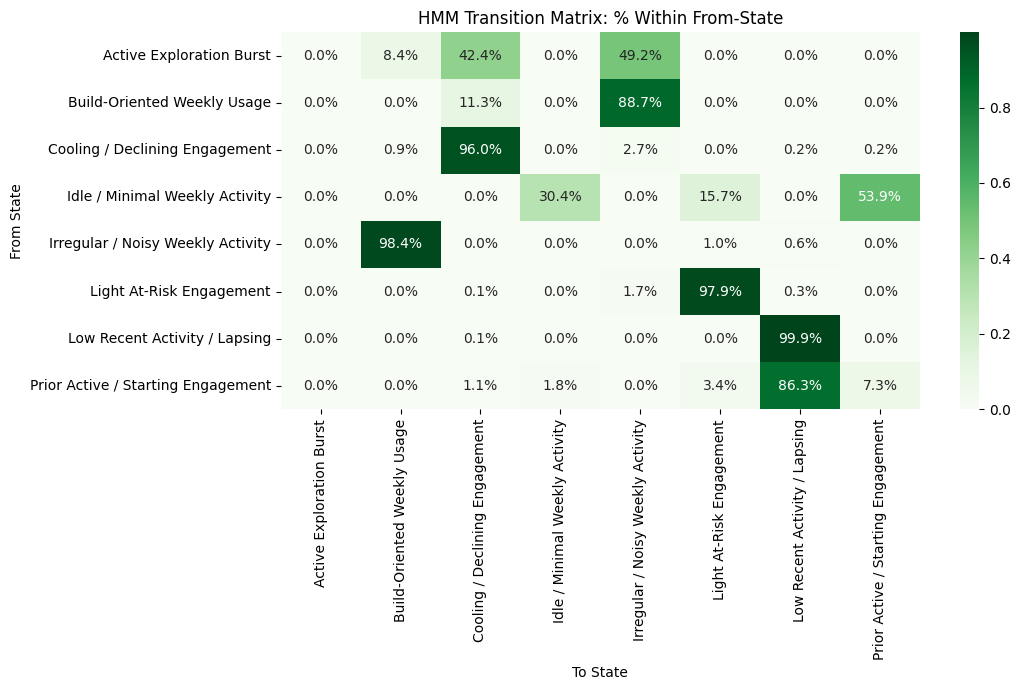

In [23]:
con.execute(f"""
CREATE OR REPLACE TABLE {HMM_STATE_ASSET_USAGE_TABLE} AS
SELECT
    s.hmm_state,
    lbl.hmm_state_label AS state_label,
    asset_name,
    asset_group,
    asset_role,
    COUNT(*) AS developer_weeks,
    SUM(used_asset_flag) AS exposed_developer_weeks,
    COUNT(DISTINCT s.developer_id) AS distinct_developers_seen,
    COUNT(DISTINCT CASE WHEN used_asset_flag = 1 THEN s.developer_id END) AS distinct_developers_using_asset,
    AVG(used_asset_flag) AS exposure_rate,
    AVG(CASE WHEN used_asset_flag = 1 THEN event_count END) AS avg_event_count_when_used,
    AVG(CASE WHEN used_asset_flag = 1 THEN activity_score_sum END) AS avg_score_when_used,
    ROW_NUMBER() OVER (
        PARTITION BY s.hmm_state
        ORDER BY AVG(used_asset_flag) DESC,
                 COUNT(DISTINCT CASE WHEN used_asset_flag = 1 THEN s.developer_id END) DESC,
                 asset_name
    ) AS asset_rank_within_state
FROM {HMM_STATE_ASSET_LONG_TABLE} s
LEFT JOIN {HMM_STATE_LABEL_TABLE} lbl
  ON s.hmm_state = lbl.hmm_state
GROUP BY 1,2,3,4,5
""")

con.execute(f"""
CREATE OR REPLACE TABLE {HMM_TRANSITION_EVENT_TABLE} AS
WITH ordered AS (
    SELECT
        developer_id,
        week_start AS from_week_start,
        hmm_state AS from_state,
        LEAD(week_start) OVER (PARTITION BY developer_id ORDER BY week_start) AS to_week_start,
        LEAD(hmm_state) OVER (PARTITION BY developer_id ORDER BY week_start) AS to_state,
        stratum,
        adoption_direction
    FROM {HMM_WEEKLY_TABLE}
)
SELECT
    developer_id,
    from_week_start,
    to_week_start,
    from_state,
    to_state,
    stratum,
    adoption_direction,
    developer_id || '|' || CAST(to_week_start AS VARCHAR) || '|' || CAST(from_state AS VARCHAR) || '|' || CAST(to_state AS VARCHAR) AS transition_id
FROM ordered
WHERE to_state IS NOT NULL
  AND to_week_start = from_week_start + INTERVAL 7 DAYS
""")

con.execute(f"""
CREATE OR REPLACE TABLE {HMM_TRANSITION_SUMMARY_TABLE} AS
WITH pair_counts AS (
    SELECT
        from_state,
        to_state,
        COUNT(*) AS transitions,
        COUNT(DISTINCT developer_id) AS distinct_developers
    FROM {HMM_TRANSITION_EVENT_TABLE}
    GROUP BY 1,2
)
SELECT
    p.from_state,
    p.to_state,
    lf.hmm_state_label AS from_state_label,
    lt.hmm_state_label AS to_state_label,
    transitions,
    distinct_developers,
    transitions * 1.0 / NULLIF(SUM(transitions) OVER (PARTITION BY from_state), 0) AS pct_within_from_state,
    CASE WHEN from_state = to_state THEN 1 ELSE 0 END AS same_state_flag
FROM pair_counts p
LEFT JOIN {HMM_STATE_LABEL_TABLE} lf ON p.from_state = lf.hmm_state
LEFT JOIN {HMM_STATE_LABEL_TABLE} lt ON p.to_state = lt.hmm_state
ORDER BY from_state, transitions DESC, to_state
""")

con.execute(f"""
CREATE OR REPLACE TABLE {HMM_TRANSITION_CONTEXT_TABLE} AS
WITH ctx_counts AS (
    SELECT from_state, to_state, stratum, adoption_direction,
           COUNT(*) AS transitions,
           COUNT(DISTINCT developer_id) AS distinct_developers
    FROM {HMM_TRANSITION_EVENT_TABLE}
    GROUP BY 1,2,3,4
)
SELECT
    c.from_state,
    c.to_state,
    lf.hmm_state_label AS from_state_label,
    lt.hmm_state_label AS to_state_label,
    stratum,
    adoption_direction,
    transitions,
    distinct_developers,
    transitions * 1.0 / NULLIF(SUM(transitions) OVER (PARTITION BY from_state, to_state), 0) AS pct_within_transition_pair
FROM ctx_counts c
LEFT JOIN {HMM_STATE_LABEL_TABLE} lf ON c.from_state = lf.hmm_state
LEFT JOIN {HMM_STATE_LABEL_TABLE} lt ON c.to_state = lt.hmm_state
ORDER BY transitions DESC, from_state, to_state, stratum, adoption_direction
""")

display(Markdown('### Top Assets Within Each HMM State'))
display(con.execute(f"SELECT * FROM {HMM_STATE_ASSET_USAGE_TABLE} WHERE asset_rank_within_state <= 10 ORDER BY hmm_state, asset_rank_within_state").fetchdf())
display(Markdown('### Most Frequent Transition Pairs'))
display(con.execute(f"SELECT * FROM {HMM_TRANSITION_SUMMARY_TABLE} ORDER BY transitions DESC LIMIT 40").fetchdf())
display(Markdown('### Transition Pair Context Breakout'))
display(con.execute(f"SELECT * FROM {HMM_TRANSITION_CONTEXT_TABLE} ORDER BY transitions DESC LIMIT 40").fetchdf())

transition_heat = con.execute(f"SELECT * FROM {HMM_TRANSITION_SUMMARY_TABLE}").fetchdf()
heat = transition_heat.pivot_table(index='from_state_label', columns='to_state_label', values='pct_within_from_state', fill_value=0)
fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(heat, annot=True, fmt='.1%', cmap='Greens', ax=ax)
ax.set_title('HMM Transition Matrix: % Within From-State')
ax.set_xlabel('To State')
ax.set_ylabel('From State')
plt.tight_layout()
plt.show()


## 5. Pre/Post Transition Assets And Important Transition Visuals

This section measures which assets show up before and after each HMM transition pair, computes post-vs-pre lift, and plots the highest-volume non-self transitions using readable HMM state labels.


### Top Assets Before Each Transition Pair

,from_state,to_state,from_state_label,to_state_label,asset_name,asset_group,asset_role,transition_windows,transition_windows_using_asset,asset_window_rate,avg_event_count_when_present,avg_activity_score_when_present,asset_rank_within_transition
0,0,2,Idle / Minimal Weekly Activity,Light At-Risk Engagement,devzone_download,download_activity,download,1113,440.0,0.395328,11.177273,30.390909,1
1,0,2,Idle / Minimal Weekly Activity,Light At-Risk Engagement,program_membership,program_activity,program,1113,304.0,0.273136,1.029605,1.046053,2
2,0,2,Idle / Minimal Weekly Activity,Light At-Risk Engagement,live_event,event_activity,live_event,1113,117.0,0.105121,4.162393,41.623932,3
3,0,2,Idle / Minimal Weekly Activity,Light At-Risk Engagement,ngc_download,download_activity,download,1113,95.0,0.085355,5.442105,21.684211,4
4,0,2,Idle / Minimal Weekly Activity,Light At-Risk Engagement,dli_training,learning_activity,course_engagement,1113,58.0,0.052111,1.465517,37.931034,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,7,5,Irregular / Noisy Weekly Activity,Build-Oriented Weekly Usage,program_membership,program_activity,program,5817,814.0,0.139935,1.132678,1.093366,4
188,7,5,Irregular / Noisy Weekly Activity,Build-Oriented Weekly Usage,model_api,product_activity,api_usage,5817,321.0,0.055183,131.236760,0.000000,5
189,7,5,Irregular / Noisy Weekly Activity,Build-Oriented Weekly Usage,dli_training,learning_activity,course_engagement,5817,291.0,0.050026,1.690722,37.938144,6
190,7,5,Irregular / Noisy Weekly Activity,Build-Oriented Weekly Usage,ondemand_view,content_activity,content,5817,267.0,0.045900,3.591760,51.629213,7


### Top Assets After Each Transition Pair

,from_state,to_state,from_state_label,to_state_label,asset_name,asset_group,asset_role,transition_windows,transition_windows_using_asset,asset_window_rate,avg_event_count_when_present,avg_activity_score_when_present,asset_rank_within_transition
0,0,2,Idle / Minimal Weekly Activity,Light At-Risk Engagement,devzone_download,download_activity,download,1113,619.0,0.556155,14.379645,38.945073,1
1,0,2,Idle / Minimal Weekly Activity,Light At-Risk Engagement,live_event,event_activity,live_event,1113,219.0,0.196765,6.515982,65.159817,2
2,0,2,Idle / Minimal Weekly Activity,Light At-Risk Engagement,ondemand_view,content_activity,content,1113,198.0,0.177898,9.111111,27.474747,3
3,0,2,Idle / Minimal Weekly Activity,Light At-Risk Engagement,program_membership,program_activity,program,1113,182.0,0.163522,1.197802,1.032967,4
4,0,2,Idle / Minimal Weekly Activity,Light At-Risk Engagement,dli_training,learning_activity,course_engagement,1113,151.0,0.135669,2.456954,69.801325,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,7,5,Irregular / Noisy Weekly Activity,Build-Oriented Weekly Usage,model_api,product_activity,api_usage,5817,299.0,0.051401,133.471572,0.000000,4
188,7,5,Irregular / Noisy Weekly Activity,Build-Oriented Weekly Usage,ondemand_view,content_activity,content,5817,238.0,0.040915,5.239496,65.067227,5
189,7,5,Irregular / Noisy Weekly Activity,Build-Oriented Weekly Usage,dli_training,learning_activity,course_engagement,5817,205.0,0.035242,1.517073,34.829268,6
190,7,5,Irregular / Noisy Weekly Activity,Build-Oriented Weekly Usage,program_membership,program_activity,program,5817,184.0,0.031631,1.054348,0.961957,7


### Assets With Largest Post Minus Pre Lift

,from_state,to_state,from_state_label,to_state_label,asset_name,transitions_for_pair,pre_asset_window_rate,post_asset_window_rate,post_minus_pre_rate,pre_avg_event_count_when_present,post_avg_event_count_when_present,post_minus_pre_event_count,pre_avg_activity_score_when_present,post_avg_activity_score_when_present,post_minus_pre_activity_score
0,3,5,Cooling / Declining Engagement,Build-Oriented Weekly Usage,forum_contribution,111,0.108108,0.882883,0.774775,2.416667,6.714286,4.297619,7.250000,15.897959,8.647959
1,2,7,Light At-Risk Engagement,Irregular / Noisy Weekly Activity,forum_contribution,362,0.005525,0.756906,0.751381,2.000000,5.693431,3.693431,15.500000,15.142336,-0.357664
2,3,7,Cooling / Declining Engagement,Irregular / Noisy Weekly Activity,forum_contribution,331,0.169184,0.794562,0.625378,2.250000,8.216730,5.966730,9.178571,20.125475,10.946904
3,4,5,Active Exploration Burst,Build-Oriented Weekly Usage,forum_contribution,120,0.450000,0.833333,0.383333,2.407407,7.120000,4.712593,8.703704,17.330000,8.626296
4,6,3,Prior Active / Starting Engagement,Cooling / Declining Engagement,forum_contribution,489,0.000000,0.310838,0.310838,NaN,2.381579,NaN,NaN,8.315789,NaN
5,4,7,Active Exploration Burst,Irregular / Noisy Weekly Activity,forum_contribution,706,0.492918,0.781870,0.288952,3.166667,6.572464,3.405797,9.844828,16.293478,6.448651
6,0,6,Idle / Minimal Weekly Activity,Prior Active / Starting Engagement,ondemand_view,3819,0.024352,0.303744,0.279393,8.354839,5.696552,-2.658287,25.365591,17.627586,-7.738005
7,0,6,Idle / Minimal Weekly Activity,Prior Active / Starting Engagement,devzone_download,3819,0.337785,0.527625,0.189840,7.652713,6.598015,-1.054698,21.160465,18.294789,-2.865676
8,0,2,Idle / Minimal Weekly Activity,Light At-Risk Engagement,ondemand_view,1113,0.010782,0.177898,0.167116,3.750000,9.111111,5.361111,11.833333,27.474747,15.641414
9,0,2,Idle / Minimal Weekly Activity,Light At-Risk Engagement,devzone_download,1113,0.395328,0.556155,0.160827,11.177273,14.379645,3.202372,30.390909,38.945073,8.554164


### Pre-Transition Context Breakout

,from_state,to_state,from_state_label,to_state_label,stratum,adoption_direction,asset_name,asset_group,asset_role,transition_windows,transition_windows_using_asset,asset_window_rate,avg_event_count_when_present,avg_activity_score_when_present
0,6,1,Prior Active / Starting Engagement,Low Recent Activity / Lapsing,dormant,steady_inactive,contest,community_activity,community,19989,0.0,0.000000,NaN,NaN
1,6,1,Prior Active / Starting Engagement,Low Recent Activity / Lapsing,dormant,steady_inactive,webinar,learning_activity,event_learning,19989,136.0,0.006804,1.852941,11.507353
2,6,1,Prior Active / Starting Engagement,Low Recent Activity / Lapsing,dormant,steady_inactive,ngc_download,download_activity,download,19989,483.0,0.024163,8.099379,37.337474
3,6,1,Prior Active / Starting Engagement,Low Recent Activity / Lapsing,dormant,steady_inactive,model_api,product_activity,api_usage,19989,736.0,0.036820,3.402174,0.000000
4,6,1,Prior Active / Starting Engagement,Low Recent Activity / Lapsing,dormant,steady_inactive,ondemand_view,content_activity,content,19989,907.0,0.045375,4.743109,14.476295
5,6,1,Prior Active / Starting Engagement,Low Recent Activity / Lapsing,dormant,steady_inactive,bug_filed,community_activity,community,19989,30.0,0.001501,2.133333,6.400000
6,6,1,Prior Active / Starting Engagement,Low Recent Activity / Lapsing,dormant,steady_inactive,hackathon,community_activity,community,19989,0.0,0.000000,NaN,NaN
7,6,1,Prior Active / Starting Engagement,Low Recent Activity / Lapsing,dormant,steady_inactive,live_event,event_activity,live_event,19989,1065.0,0.053279,6.293897,62.919249
8,6,1,Prior Active / Starting Engagement,Low Recent Activity / Lapsing,dormant,steady_inactive,dli_training,learning_activity,course_engagement,19989,1057.0,0.052879,1.714286,48.420057
9,6,1,Prior Active / Starting Engagement,Low Recent Activity / Lapsing,dormant,steady_inactive,program_membership,program_activity,program,19989,14435.0,0.722147,1.051611,1.071285


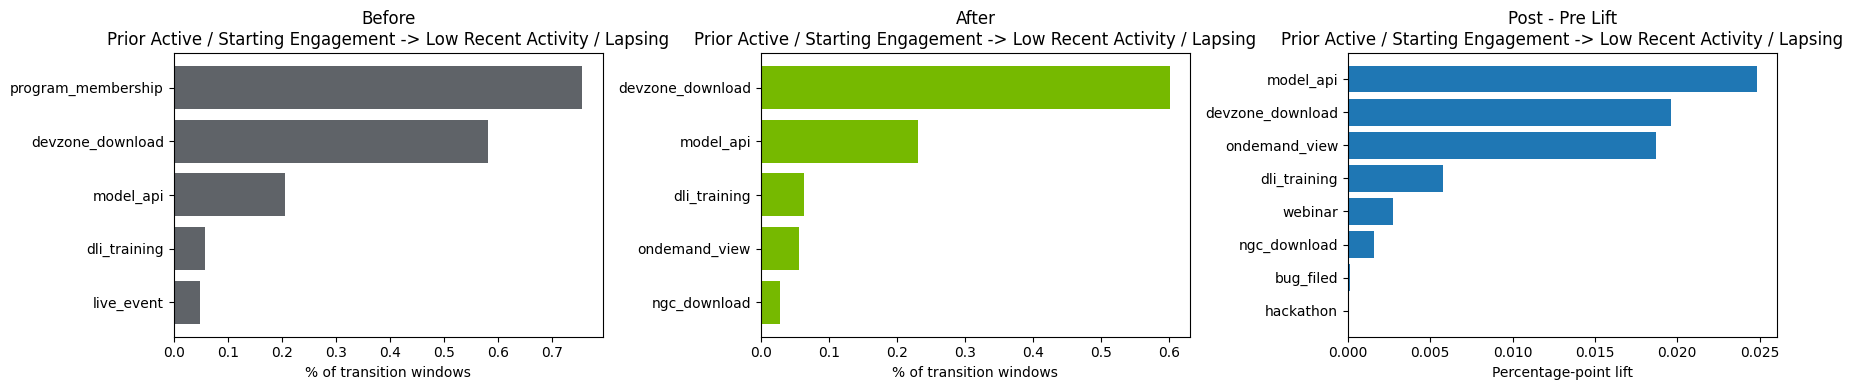

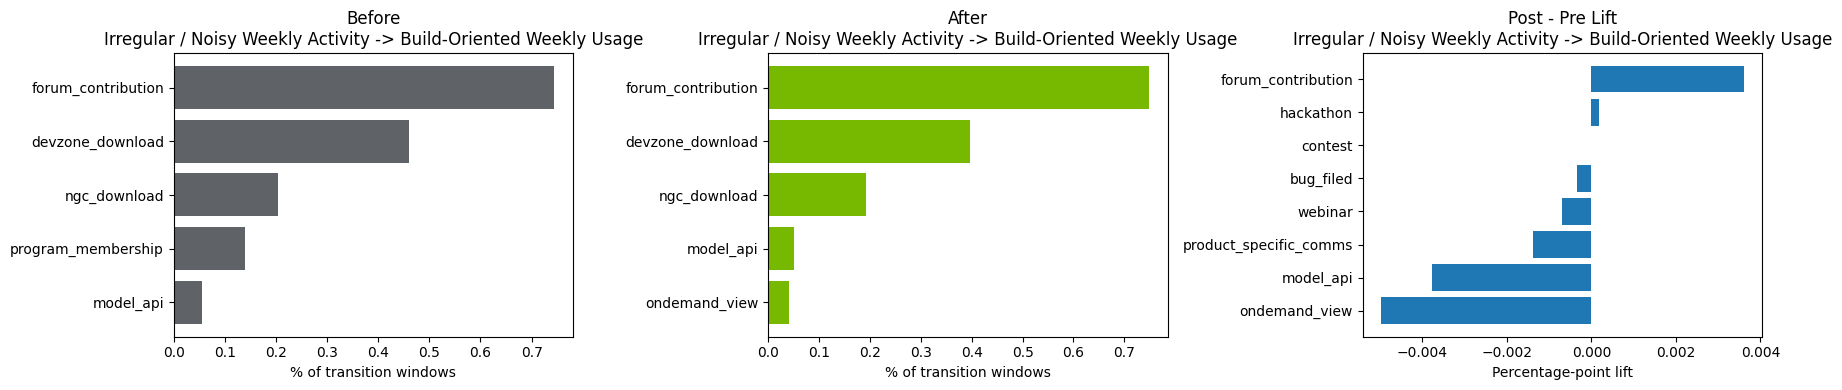

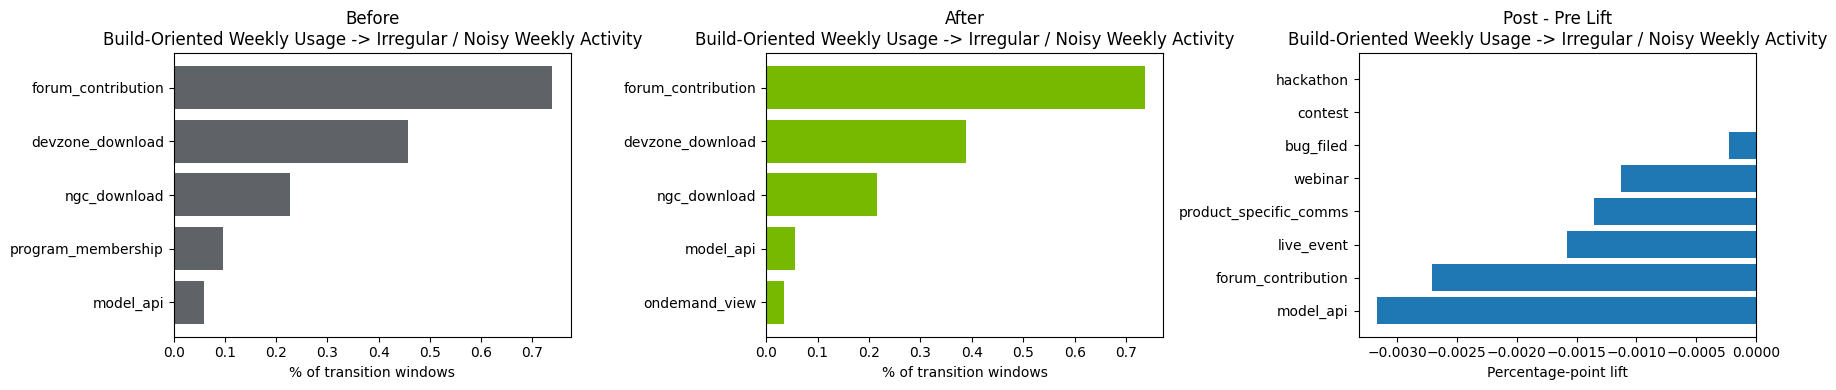

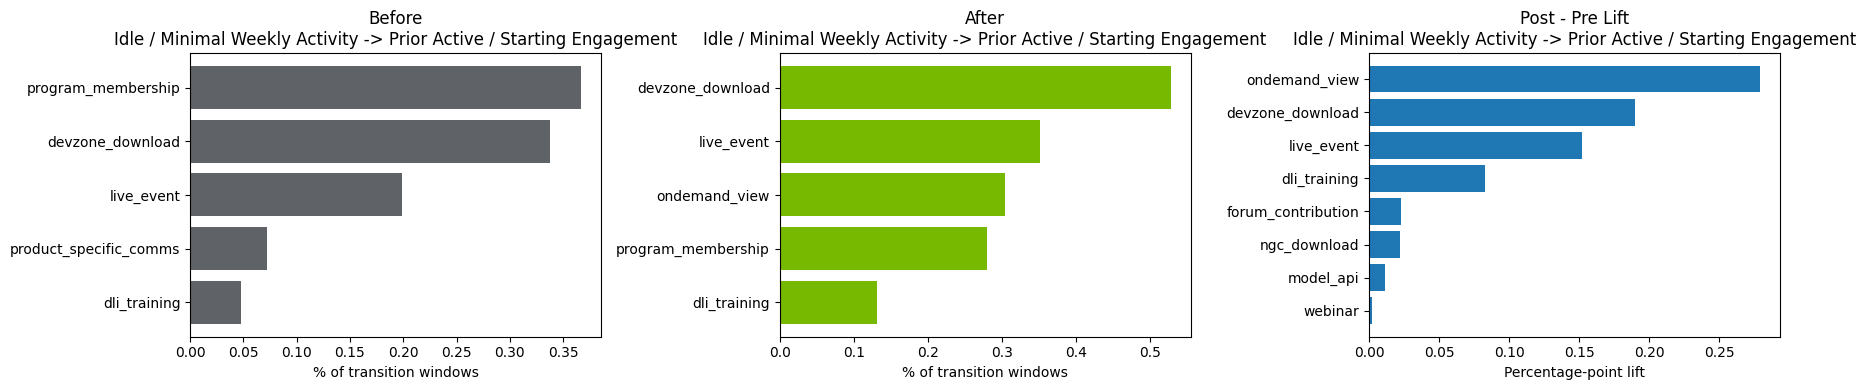

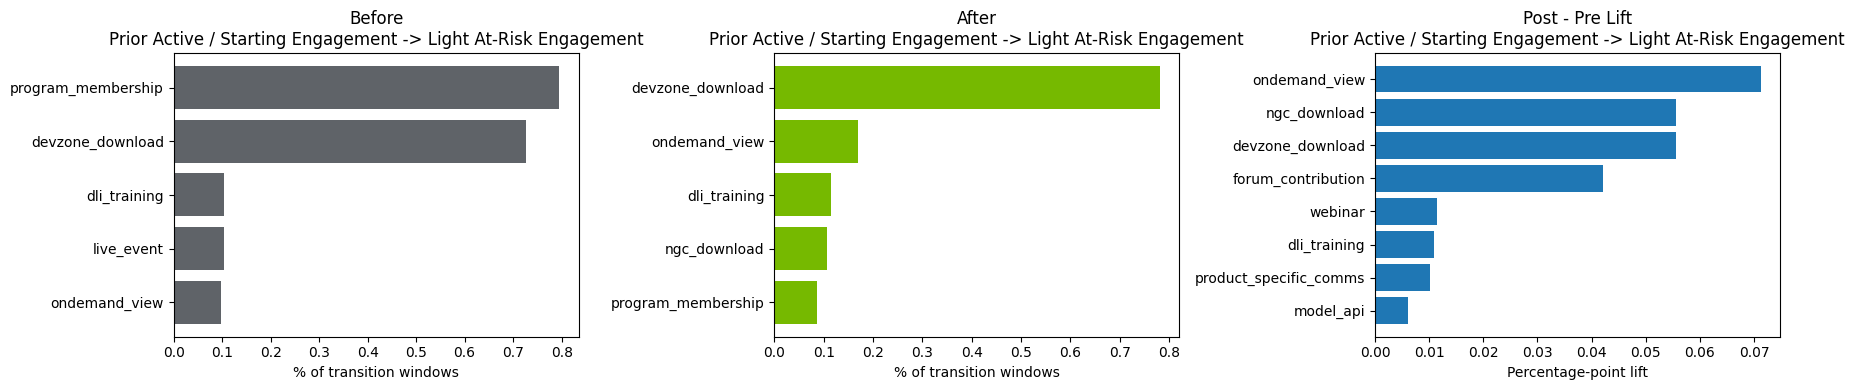

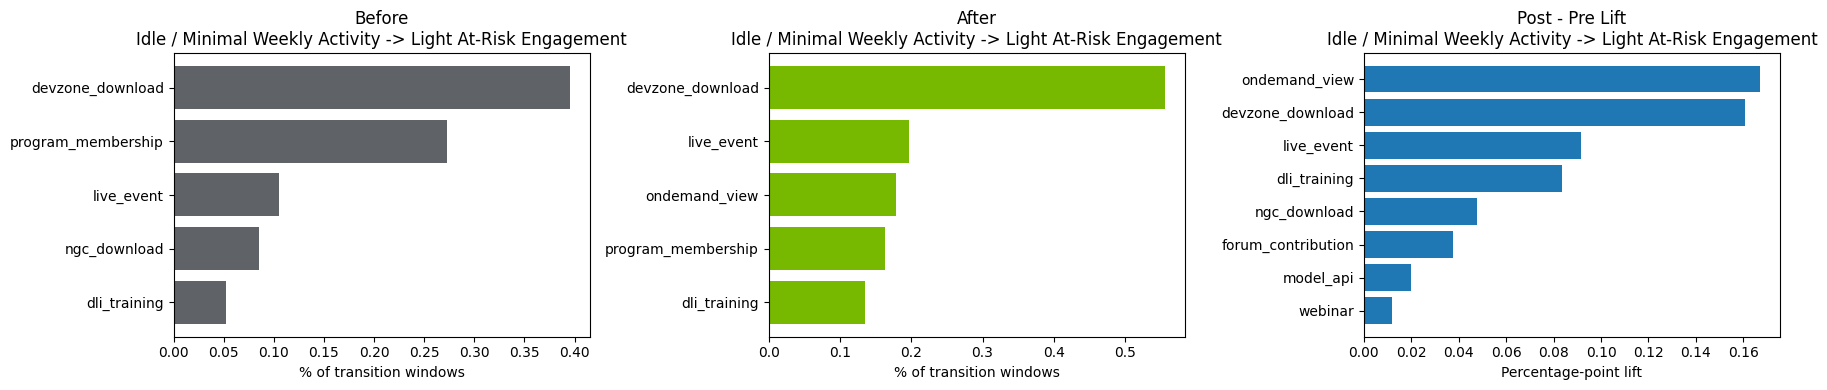

### Dominant HMM State Profile

,dominant_hmm_state,persona,behavior_journey_stage_30d,current_journey_state_30d,dormancy_status,developer_effort_level,developers,avg_weeks,avg_state_probability,avg_hmm_state_entropy
0,0,CUDA,Historically_Active,Dormant_Historically_Active,Dormant,medium effort,2020,3.243069,0.636037,0.937393
1,0,CUDA,Historically_Active,Dormant_Historically_Active,Dormant,high effort,1713,3.841214,0.600322,0.927770
2,0,CUDA,Historically_Active,At_Risk_Historically_Active,At_Risk,high effort,458,3.534934,0.607262,0.896394
3,0,CUDA,Historically_Active,At_Risk_Historically_Active,At_Risk,medium effort,375,3.288000,0.639417,0.954781
4,0,GenAI,Historically_Active,Dormant_Historically_Active,Dormant,high effort,361,3.443213,0.626307,0.931565
5,0,Learning_Community,Historically_Active,Dormant_Historically_Active,Dormant,high effort,297,3.535354,0.615968,0.907938
6,0,GenAI,Historically_Active,At_Risk_Historically_Active,At_Risk,high effort,271,3.435424,0.605611,0.868901
7,0,CUDA,Builder,Dormant_Builder,Dormant,high effort,246,4.166667,0.558688,0.910266
8,0,Robotics,Historically_Active,Dormant_Historically_Active,Dormant,high effort,228,3.657895,0.604035,0.945518
9,0,GenAI,Historically_Active,Dormant_Historically_Active,Dormant,medium effort,222,3.184685,0.629205,0.918565


In [24]:
con.execute(f"""
CREATE OR REPLACE TABLE {HMM_PRE_TRANSITION_ASSET_TABLE} AS
WITH windowed AS (
    SELECT
        t.transition_id, t.from_state, t.to_state, t.stratum, t.adoption_direction,
        l.asset_name, l.asset_group, l.asset_role,
        MAX(l.used_asset_flag) AS used_asset_in_window,
        SUM(l.event_count) AS total_event_count,
        SUM(l.activity_score_sum) AS total_activity_score
    FROM {HMM_TRANSITION_EVENT_TABLE} t
    JOIN {HMM_STATE_ASSET_LONG_TABLE} l
      ON t.developer_id = l.developer_id
     AND l.week_start >= t.to_week_start - INTERVAL {PRE_WEEKS} WEEKS
     AND l.week_start < t.to_week_start
    GROUP BY 1,2,3,4,5,6,7,8
)
SELECT
    w.from_state, w.to_state,
    lf.hmm_state_label AS from_state_label,
    lt.hmm_state_label AS to_state_label,
    asset_name, asset_group, asset_role,
    COUNT(*) AS transition_windows,
    SUM(used_asset_in_window) AS transition_windows_using_asset,
    AVG(used_asset_in_window) AS asset_window_rate,
    AVG(CASE WHEN used_asset_in_window = 1 THEN total_event_count END) AS avg_event_count_when_present,
    AVG(CASE WHEN used_asset_in_window = 1 THEN total_activity_score END) AS avg_activity_score_when_present,
    ROW_NUMBER() OVER (
        PARTITION BY from_state, to_state
        ORDER BY AVG(used_asset_in_window) DESC,
                 SUM(used_asset_in_window) DESC,
                 asset_name
    ) AS asset_rank_within_transition
FROM windowed w
LEFT JOIN {HMM_STATE_LABEL_TABLE} lf ON w.from_state = lf.hmm_state
LEFT JOIN {HMM_STATE_LABEL_TABLE} lt ON w.to_state = lt.hmm_state
GROUP BY 1,2,3,4,5,6,7
""")

con.execute(f"""
CREATE OR REPLACE TABLE {HMM_PRE_TRANSITION_ASSET_CONTEXT_TABLE} AS
WITH windowed AS (
    SELECT
        t.transition_id, t.from_state, t.to_state, t.stratum, t.adoption_direction,
        l.asset_name, l.asset_group, l.asset_role,
        MAX(l.used_asset_flag) AS used_asset_in_window,
        SUM(l.event_count) AS total_event_count,
        SUM(l.activity_score_sum) AS total_activity_score
    FROM {HMM_TRANSITION_EVENT_TABLE} t
    JOIN {HMM_STATE_ASSET_LONG_TABLE} l
      ON t.developer_id = l.developer_id
     AND l.week_start >= t.to_week_start - INTERVAL {PRE_WEEKS} WEEKS
     AND l.week_start < t.to_week_start
    GROUP BY 1,2,3,4,5,6,7,8
)
SELECT
    w.from_state, w.to_state,
    lf.hmm_state_label AS from_state_label,
    lt.hmm_state_label AS to_state_label,
    stratum, adoption_direction, asset_name, asset_group, asset_role,
    COUNT(*) AS transition_windows,
    SUM(used_asset_in_window) AS transition_windows_using_asset,
    AVG(used_asset_in_window) AS asset_window_rate,
    AVG(CASE WHEN used_asset_in_window = 1 THEN total_event_count END) AS avg_event_count_when_present,
    AVG(CASE WHEN used_asset_in_window = 1 THEN total_activity_score END) AS avg_activity_score_when_present
FROM windowed w
LEFT JOIN {HMM_STATE_LABEL_TABLE} lf ON w.from_state = lf.hmm_state
LEFT JOIN {HMM_STATE_LABEL_TABLE} lt ON w.to_state = lt.hmm_state
GROUP BY 1,2,3,4,5,6,7,8,9
""")

con.execute(f"""
CREATE OR REPLACE TABLE {HMM_POST_TRANSITION_ASSET_TABLE} AS
WITH windowed AS (
    SELECT
        t.transition_id, t.from_state, t.to_state, t.stratum, t.adoption_direction,
        l.asset_name, l.asset_group, l.asset_role,
        MAX(l.used_asset_flag) AS used_asset_in_window,
        SUM(l.event_count) AS total_event_count,
        SUM(l.activity_score_sum) AS total_activity_score
    FROM {HMM_TRANSITION_EVENT_TABLE} t
    JOIN {HMM_STATE_ASSET_LONG_TABLE} l
      ON t.developer_id = l.developer_id
     AND l.week_start >= t.to_week_start
     AND l.week_start < t.to_week_start + INTERVAL {POST_WEEKS} WEEKS
    GROUP BY 1,2,3,4,5,6,7,8
)
SELECT
    w.from_state, w.to_state,
    lf.hmm_state_label AS from_state_label,
    lt.hmm_state_label AS to_state_label,
    asset_name, asset_group, asset_role,
    COUNT(*) AS transition_windows,
    SUM(used_asset_in_window) AS transition_windows_using_asset,
    AVG(used_asset_in_window) AS asset_window_rate,
    AVG(CASE WHEN used_asset_in_window = 1 THEN total_event_count END) AS avg_event_count_when_present,
    AVG(CASE WHEN used_asset_in_window = 1 THEN total_activity_score END) AS avg_activity_score_when_present,
    ROW_NUMBER() OVER (
        PARTITION BY from_state, to_state
        ORDER BY AVG(used_asset_in_window) DESC,
                 SUM(used_asset_in_window) DESC,
                 asset_name
    ) AS asset_rank_within_transition
FROM windowed w
LEFT JOIN {HMM_STATE_LABEL_TABLE} lf ON w.from_state = lf.hmm_state
LEFT JOIN {HMM_STATE_LABEL_TABLE} lt ON w.to_state = lt.hmm_state
GROUP BY 1,2,3,4,5,6,7
""")

con.execute(f"""
CREATE OR REPLACE TABLE {HMM_POST_TRANSITION_ASSET_CONTEXT_TABLE} AS
WITH windowed AS (
    SELECT
        t.transition_id, t.from_state, t.to_state, t.stratum, t.adoption_direction,
        l.asset_name, l.asset_group, l.asset_role,
        MAX(l.used_asset_flag) AS used_asset_in_window,
        SUM(l.event_count) AS total_event_count,
        SUM(l.activity_score_sum) AS total_activity_score
    FROM {HMM_TRANSITION_EVENT_TABLE} t
    JOIN {HMM_STATE_ASSET_LONG_TABLE} l
      ON t.developer_id = l.developer_id
     AND l.week_start >= t.to_week_start
     AND l.week_start < t.to_week_start + INTERVAL {POST_WEEKS} WEEKS
    GROUP BY 1,2,3,4,5,6,7,8
)
SELECT
    w.from_state, w.to_state,
    lf.hmm_state_label AS from_state_label,
    lt.hmm_state_label AS to_state_label,
    stratum, adoption_direction, asset_name, asset_group, asset_role,
    COUNT(*) AS transition_windows,
    SUM(used_asset_in_window) AS transition_windows_using_asset,
    AVG(used_asset_in_window) AS asset_window_rate,
    AVG(CASE WHEN used_asset_in_window = 1 THEN total_event_count END) AS avg_event_count_when_present,
    AVG(CASE WHEN used_asset_in_window = 1 THEN total_activity_score END) AS avg_activity_score_when_present
FROM windowed w
LEFT JOIN {HMM_STATE_LABEL_TABLE} lf ON w.from_state = lf.hmm_state
LEFT JOIN {HMM_STATE_LABEL_TABLE} lt ON w.to_state = lt.hmm_state
GROUP BY 1,2,3,4,5,6,7,8,9
""")

con.execute(f"""
CREATE OR REPLACE TABLE {HMM_TRANSITION_ASSET_DELTA_TABLE} AS
WITH pair_sizes AS (
    SELECT from_state, to_state, COUNT(*) AS transitions
    FROM {HMM_TRANSITION_EVENT_TABLE}
    GROUP BY 1,2
)
SELECT
    COALESCE(pre.from_state, post.from_state) AS from_state,
    COALESCE(pre.to_state, post.to_state) AS to_state,
    COALESCE(pre.from_state_label, post.from_state_label) AS from_state_label,
    COALESCE(pre.to_state_label, post.to_state_label) AS to_state_label,
    COALESCE(pre.asset_name, post.asset_name) AS asset_name,
    sizes.transitions AS transitions_for_pair,
    pre.asset_window_rate AS pre_asset_window_rate,
    post.asset_window_rate AS post_asset_window_rate,
    post.asset_window_rate - pre.asset_window_rate AS post_minus_pre_rate,
    pre.avg_event_count_when_present AS pre_avg_event_count_when_present,
    post.avg_event_count_when_present AS post_avg_event_count_when_present,
    post.avg_event_count_when_present - pre.avg_event_count_when_present AS post_minus_pre_event_count,
    pre.avg_activity_score_when_present AS pre_avg_activity_score_when_present,
    post.avg_activity_score_when_present AS post_avg_activity_score_when_present,
    post.avg_activity_score_when_present - pre.avg_activity_score_when_present AS post_minus_pre_activity_score
FROM {HMM_PRE_TRANSITION_ASSET_TABLE} pre
FULL OUTER JOIN {HMM_POST_TRANSITION_ASSET_TABLE} post
  ON pre.from_state = post.from_state
 AND pre.to_state = post.to_state
 AND pre.asset_name = post.asset_name
LEFT JOIN pair_sizes sizes
  ON COALESCE(pre.from_state, post.from_state) = sizes.from_state
 AND COALESCE(pre.to_state, post.to_state) = sizes.to_state
WHERE sizes.transitions >= {MIN_TRANSITIONS_PER_PAIR}
""")

con.execute(f"""
CREATE OR REPLACE TABLE {HMM_DOMINANT_STATE_PROFILE_TABLE} AS
SELECT
    j.dominant_hmm_state,
    p.persona,
    p.behavior_journey_stage_30d,
    p.current_journey_state_30d,
    p.dormancy_status,
    p.developer_effort_level,
    COUNT(*) AS developers,
    AVG(j.n_weeks) AS avg_weeks,
    AVG(j.avg_state_probability) AS avg_state_probability,
    AVG(j.hmm_state_entropy) AS avg_hmm_state_entropy
FROM read_parquet('{HMM_JOURNEY_SOURCE}') j
LEFT JOIN {PROFILE_TABLE} p USING (developer_id)
GROUP BY 1,2,3,4,5,6
""")

display(Markdown('### Top Assets Before Each Transition Pair'))
display(con.execute(f"SELECT * FROM {HMM_PRE_TRANSITION_ASSET_TABLE} WHERE asset_rank_within_transition <= 8 AND from_state <> to_state ORDER BY from_state, to_state, asset_rank_within_transition").fetchdf())
display(Markdown('### Top Assets After Each Transition Pair'))
display(con.execute(f"SELECT * FROM {HMM_POST_TRANSITION_ASSET_TABLE} WHERE asset_rank_within_transition <= 8 AND from_state <> to_state ORDER BY from_state, to_state, asset_rank_within_transition").fetchdf())
display(Markdown('### Assets With Largest Post Minus Pre Lift'))
display(con.execute(f"SELECT * FROM {HMM_TRANSITION_ASSET_DELTA_TABLE} WHERE from_state <> to_state ORDER BY post_minus_pre_rate DESC, transitions_for_pair DESC LIMIT 40").fetchdf())
display(Markdown('### Pre-Transition Context Breakout'))
display(con.execute(f"SELECT * FROM {HMM_PRE_TRANSITION_ASSET_CONTEXT_TABLE} WHERE from_state <> to_state ORDER BY transition_windows DESC LIMIT 40").fetchdf())

important_pairs = con.execute(f"SELECT from_state, to_state, from_state_label, to_state_label, transitions FROM {HMM_TRANSITION_SUMMARY_TABLE} WHERE from_state <> to_state ORDER BY transitions DESC LIMIT 6").fetchdf()
if len(important_pairs) > 0:
    pre_plot = con.execute(f"SELECT * FROM {HMM_PRE_TRANSITION_ASSET_TABLE} WHERE from_state <> to_state AND asset_rank_within_transition <= 5").fetchdf()
    post_plot = con.execute(f"SELECT * FROM {HMM_POST_TRANSITION_ASSET_TABLE} WHERE from_state <> to_state AND asset_rank_within_transition <= 5").fetchdf()
    delta_plot = con.execute(f"SELECT * FROM {HMM_TRANSITION_ASSET_DELTA_TABLE} WHERE from_state <> to_state ORDER BY transitions_for_pair DESC").fetchdf()
    for _, pair in important_pairs.iterrows():
        pair_key = (pair['from_state'], pair['to_state'])
        pair_title = f"{pair['from_state_label']} -> {pair['to_state_label']}"
        pre_sub = pre_plot[(pre_plot['from_state'] == pair_key[0]) & (pre_plot['to_state'] == pair_key[1])].sort_values('asset_window_rate')
        post_sub = post_plot[(post_plot['from_state'] == pair_key[0]) & (post_plot['to_state'] == pair_key[1])].sort_values('asset_window_rate')
        delta_sub = delta_plot[(delta_plot['from_state'] == pair_key[0]) & (delta_plot['to_state'] == pair_key[1])].sort_values('post_minus_pre_rate').tail(8)
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        axes[0].barh(pre_sub['asset_name'], pre_sub['asset_window_rate'], color='#5F6368')
        axes[0].set_title(f'Before\n{pair_title}')
        axes[0].set_xlabel('% of transition windows')
        axes[1].barh(post_sub['asset_name'], post_sub['asset_window_rate'], color='#76B900')
        axes[1].set_title(f'After\n{pair_title}')
        axes[1].set_xlabel('% of transition windows')
        axes[2].barh(delta_sub['asset_name'], delta_sub['post_minus_pre_rate'], color='#1F77B4')
        axes[2].set_title(f'Post - Pre Lift\n{pair_title}')
        axes[2].set_xlabel('Percentage-point lift')
        plt.tight_layout()
        plt.show()
display(Markdown('### Dominant HMM State Profile'))
display(con.execute(f"SELECT * FROM {HMM_DOMINANT_STATE_PROFILE_TABLE} ORDER BY dominant_hmm_state, developers DESC LIMIT 60").fetchdf())


## 6. Analysis Notes

What each visualization is useful for:
- Transition heatmap: the highest-level picture of HMM behavior. It shows which states are sticky and which non-self transitions are common enough to matter.
- Before chart for a transition pair: shows the assets most associated with the weeks leading into that transition. This is the best view for pre-transition signals.
- After chart for a transition pair: shows the assets most associated with the weeks immediately after the transition. This is the best view for what behavior follows the transition.
- Post - Pre Lift chart: the most important diagnostic for change. Positive values mean the asset becomes more common after the transition; negative values mean it was more characteristic before the transition.
- Transition context table: useful only after you understand the main transition pair. It helps explain which external lifecycle cohorts contribute to the transition, but it does not define the transition itself.
- Self-transitions like `0 -> 0`: these mean the developer stayed in the same HMM state from one week to the next. They are persistence signals, not movement signals.

Recommended reading order:
1. Start with the transition heatmap.
2. Focus on non-self transition pairs with the largest counts.
3. Use the Before and After charts to see which assets are common around the transition.
4. Use the Post - Pre Lift chart to see which assets actually changed the most across the transition.
5. Use `stratum` and `adoption_direction` only as secondary context, not as the transition destination.


## 6.5. Visual Interpretation

**01. Prior Active / Starting Engagement -> Low Recent Activity / Lapsing**
This is one of the clearest deterioration transitions. Before the move, `program_membership` and `devzone_download` are dominant. After the move, `devzone_download` is still strong, but `model_api`, `ondemand_view`, and `dli_training` gain share. This looks like a shift away from structured, anchored engagement and toward lighter-touch consumption and API behavior.

**02. Irregular / Noisy Weekly Activity -> Build-Oriented Weekly Usage**
This is a mild improvement transition, but not a dramatic one. `forum_contribution` is already dominant before the move and stays dominant after. `devzone_download` also remains strong. The biggest positive lift is still `forum_contribution`, while `ondemand_view` and `model_api` fall. This looks more like existing community/download behavior becoming more focused rather than a brand-new asset path.

**03. Build-Oriented Weekly Usage -> Irregular / Noisy Weekly Activity**
This is a clear weakening transition. The lift chart is mostly negative, especially for `model_api`, `forum_contribution`, `live_event`, and `product_specific_comms`. When developers leave build-oriented behavior, they are not replacing it with a new strong asset pattern. They are reducing the more committed assets and becoming less structured.

**04. Idle / Minimal Weekly Activity -> Prior Active / Starting Engagement**
This is one of the strongest reactivation visuals. The biggest lifts are `ondemand_view`, `devzone_download`, and `live_event`, with `dli_training` also improving. This looks like a real restart pattern where content, downloads, and event re-entry are associated with moving someone out of idle behavior.

**05. Prior Active / Starting Engagement -> Light At-Risk Engagement**
This is a strong early-risk pattern. Before the move, `program_membership` and `devzone_download` dominate. Afterward, `devzone_download` stays high, but `ondemand_view`, `ngc_download`, and `forum_contribution` gain share. That suggests movement into at-risk behavior is associated with less anchored engagement and more passive or utility-style activity.

**06. Idle / Minimal Weekly Activity -> Light At-Risk Engagement**
This is a weaker recovery than visual 04. The same assets matter, especially `ondemand_view`, `devzone_download`, and `live_event`, but the destination is still only light at-risk rather than a stronger prior-active state. This looks like partial re-engagement, not yet a strong recovery.

**Most valuable visuals**
1. `04_idle_to_prior_active`: clearest reactivation story.
2. `05_prior_active_to_light_at_risk`: clearest early-deterioration story.
3. `01_prior_active_to_lapsing`: shows what slipping looks like in asset terms.
4. `03_build_oriented_to_irregular`: shows loss of serious usage.

**Overall takeaway**
Across the strongest transitions, downloads and content are the most common assets around movement. `ondemand_view`, `devzone_download`, and sometimes `live_event` are the strongest reactivation-associated assets. The deterioration transitions do not look like total disappearance; they look like movement from deeper, more structured engagement toward lighter, more passive touchpoints.


## 7. Final Sanity Checks

This section prints row counts for the main intermediate and output tables so you can confirm that the pipeline built the expected state, transition, and transition-asset outputs.


In [25]:
checks = {
    HMM_WEEKLY_TABLE: f'SELECT COUNT(*) AS rows, COUNT(DISTINCT developer_id) AS distinct_developers FROM {HMM_WEEKLY_TABLE}',
    HMM_ACTIVITY_EVENTS_WEEKLY_TABLE: f'SELECT COUNT(*) AS rows, COUNT(DISTINCT asset_name) AS distinct_assets FROM {HMM_ACTIVITY_EVENTS_WEEKLY_TABLE}',
    HMM_STATE_ASSET_LONG_TABLE: f'SELECT COUNT(*) AS rows FROM {HMM_STATE_ASSET_LONG_TABLE}',
    HMM_TRANSITION_EVENT_TABLE: f'SELECT COUNT(*) AS rows, COUNT(DISTINCT transition_id) AS distinct_transitions FROM {HMM_TRANSITION_EVENT_TABLE}',
    HMM_TRANSITION_ASSET_DELTA_TABLE: f'SELECT COUNT(*) AS rows FROM {HMM_TRANSITION_ASSET_DELTA_TABLE}'
}

for table_name, sql in checks.items():
    display(Markdown(f'### {table_name}'))
    display(con.execute(sql).fetchdf())

print('HMM v2 pipeline tables created.')


### hmm_weekly_state_base_v2

,rows,distinct_developers
0,916268,150000


### hmm_activity_events_weekly_v2

,rows,distinct_assets
0,20043578,13


### hmm_state_asset_long_v2

...

### hmm_transition_events_v2

,rows,distinct_transitions
0,246445,246445


### hmm_asset_transition_delta_v2

,rows
0,260


HMM v2 pipeline tables created.


In [27]:
con.close()